In [1]:
%%capture
## [TEMPLATE BEGIN]
## おまじない：実行中のノートブック名からOUTPUT_DIRを決めるコード
from pathlib import Path
from IPython import get_ipython; ip = get_ipython()
if '__vsc_ipynb_file__' in ip.user_ns:
    ## VS Codeで実行されている場合
    THIS_NOTEBOOK_PATH = Path(ip.user_ns['__vsc_ipynb_file__'])
else:
    !pip install ipynbname
    import ipynbname; THIS_NOTEBOOK_PATH = Path(ipynbname.path())
    if "%2F" in THIS_NOTEBOOK_PATH.stem:
        ## Google Colabで実行されている場合
        colab_ip = %system hostname -I   # uses colab magic to get list from bash
        colab_ip = colab_ip[0].strip()   # returns "172.28.0.12"
        colab_port = 9000                # could use 6000, 8080, or 9000
        import requests
        filename = requests.get(f"http://{colab_ip}:{colab_port}/api/sessions").json()[0]["name"]
        THIS_NOTEBOOK_PATH = Path(filename)
    else:
        ## それ以外の場合
        THIS_NOTEBOOK_PATH = THIS_NOTEBOOK_PATH

OUTPUT_DIR = Path("figures") / THIS_NOTEBOOK_PATH.stem
## [TEMPLATE END]

In [2]:
print("File output directory:", OUTPUT_DIR)
# Create the output directory if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

File output directory: figures/_activation_functions


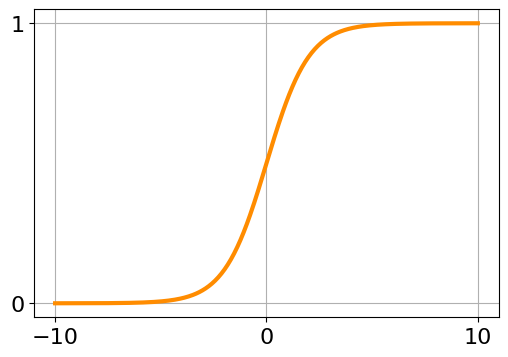

Plot saved to figures/_activation_functions/sigmoid.png


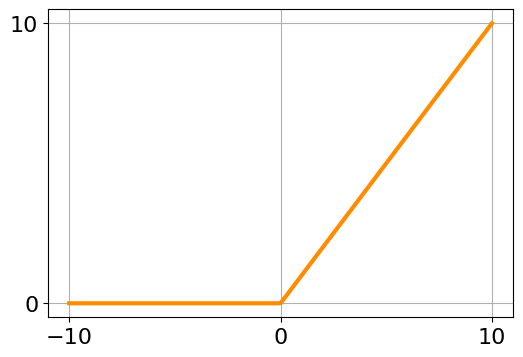

Plot saved to figures/_activation_functions/relu.png


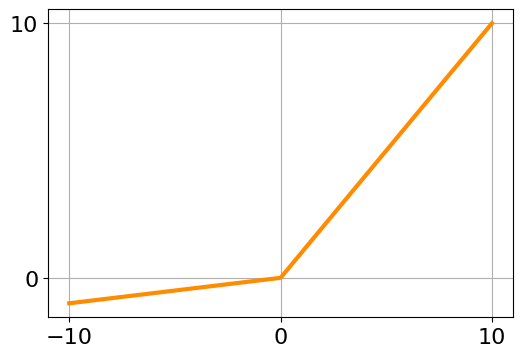

Plot saved to figures/_activation_functions/leaky_relu.png


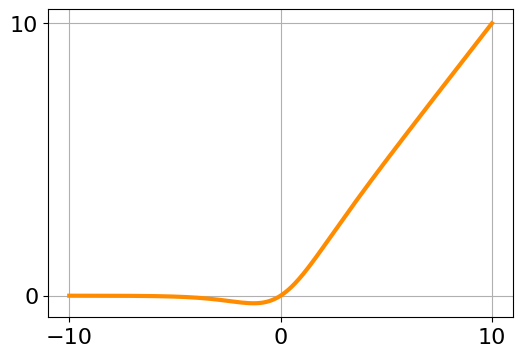

Plot saved to figures/_activation_functions/swish.png


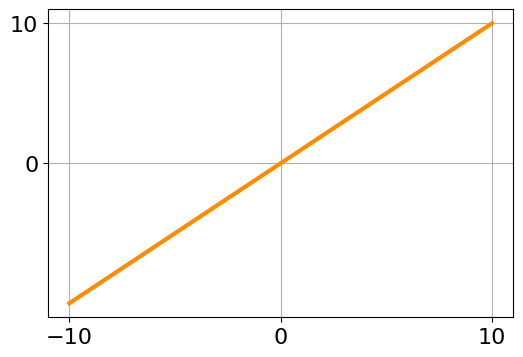

Plot saved to figures/_activation_functions/linear.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.where(x > 0, x, alpha * x)

def swish(x, beta=1):
    return x / (1 + np.exp(-beta * x))

def linear(x):
    return x

# Generate x values
x = np.linspace(-10, 10, 400)

# Define a helper function to plot and save
def plot_activation_function(x, y, filename, color, y_ticks=[0, 10]):
    plt.figure(figsize=(6, 4))
    plt.plot(x, y, color=color, linewidth=3)
    plt.xticks([-10, 0, 10], fontsize=16)
    plt.yticks(y_ticks, fontsize=16)
    plt.grid(True)
    
    # Save the figure without any axis labels but with ticks
    output_path = OUTPUT_DIR / filename
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()
    plt.close()  # Close the plot to avoid overlap in subsequent plots
    print(f"Plot saved to {output_path}")

# Plot and save each activation function separately
plot_activation_function(x, sigmoid(x), 'sigmoid.png', '#FF8C00', [0, 1])         # Blue for Sigmoid
plot_activation_function(x, relu(x), 'relu.png', '#FF8C00')               # Green for ReLU
plot_activation_function(x, leaky_relu(x), 'leaky_relu.png', '#FF8C00')   # Orange for Leaky ReLU
plot_activation_function(x, swish(x), 'swish.png', '#FF8C00')             # Purple for Swish (β=1)
plot_activation_function(x, linear(x), 'linear.png', '#FF8C00')           # Black for Linear